# UNSW-NB15 Intrusion Detection — Extended Notebook (More Supervised + More Anomaly Detection)

Run **cell-by-cell**.

**Datasets (local files):**
- `UNSW_NB15_training-set.csv`
- `UNSW_NB15_testing-set.csv`
- `NUSW-NB15_features.csv`

**Tasks covered:**
1. Data pre-processing & EDA
2. Classical unsupervised anomaly detection (train on normal-only)
3. Supervised intrusion classification (more models + optional SMOTE)
4. Deep learning autoencoder (train on normal-only)
5. Hyperparameter tuning + model comparison

**Extra models added:**
- Supervised: GaussianNB, Linear SVM (LinearSVC + calibration), Decision Tree, Gradient Boosting, ExtraTrees
- Unsupervised/anomaly (network-friendly baselines): kNN distance, PCA reconstruction error, EllipticEnvelope (robust covariance), plus IF/OCSVM/LOF


## 0) Setup

In [1]:

# If you run this in a fresh environment and get import errors, uncomment:
# !pip -q install imbalanced-learn tensorflow

import os
import json
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)

# Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Unsupervised / anomaly models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA

# SMOTE pipeline (supervised only)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Deep learning autoencoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", 200)
print("Ready. Seed =", SEED)


Ready. Seed = 42


## 1) Load data

In [3]:
TRAIN_PATH = "/content/UNSW_NB15_training-set.csv"
TEST_PATH  = "/content/UNSW_NB15_testing-set.csv"
FEAT_PATH  = "/content/NUSW-NB15_features.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# fix encoding here:
feat_df  = pd.read_csv(FEAT_PATH, encoding="cp1252")  # or latin-1

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Features metadata shape:", feat_df.shape)

display(train_df.head(3))
display(test_df.head(3))
display(feat_df.head(10))


Train shape: (175341, 45)
Test shape : (82332, 45)
Features metadata shape: (49, 4)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


## 2) Basic checks: duplicates, NaNs

In [4]:

print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates :", test_df.duplicated().sum())

nan_train = train_df.isna().sum().sort_values(ascending=False)
nan_test  = test_df.isna().sum().sort_values(ascending=False)
print("Top NaN columns (train):")
display(nan_train.head(15))
print("Top NaN columns (test):")
display(nan_test.head(15))


Train duplicates: 0
Test duplicates : 0
Top NaN columns (train):


,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


Top NaN columns (test):


,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


## 3) Targets and class balance


TRAIN label distribution:
label
1    119341
0     56000
Name: count, dtype: int64
label
1    0.680622
0    0.319378
Name: proportion, dtype: float64

TRAIN attack_cat distribution (top 15):


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



TEST label distribution:
label
1    45332
0    37000
Name: count, dtype: int64
label
1    0.5506
0    0.4494
Name: proportion, dtype: float64

TEST attack_cat distribution (top 15):


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


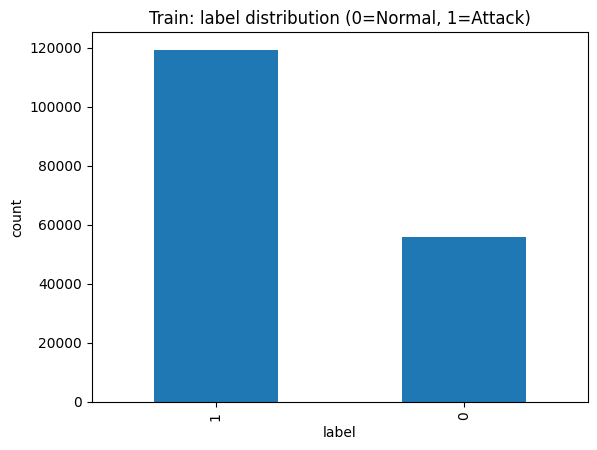

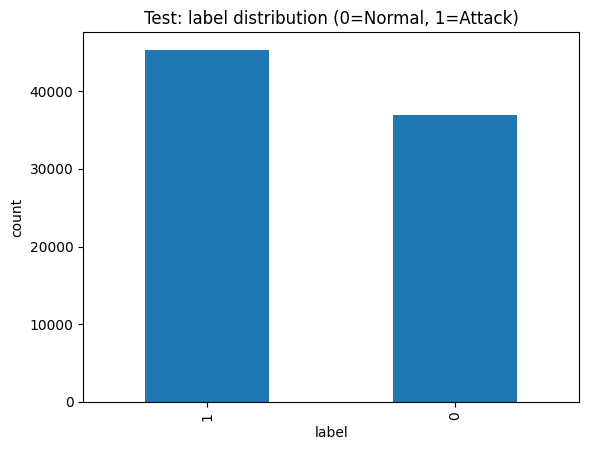

In [5]:

TARGET_BIN = "label"        # 0=normal, 1=attack
TARGET_CAT = "attack_cat"   # category (Normal, Exploits, Fuzzers, ...)

for df, name in [(train_df, "TRAIN"), (test_df, "TEST")]:
    print(f"\n{name} label distribution:")
    print(df[TARGET_BIN].value_counts())
    print(df[TARGET_BIN].value_counts(normalize=True))

    print(f"\n{name} attack_cat distribution (top 15):")
    display(df[TARGET_CAT].value_counts().head(15))

plt.figure()
train_df[TARGET_BIN].value_counts().plot(kind="bar")
plt.title("Train: label distribution (0=Normal, 1=Attack)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

plt.figure()
test_df[TARGET_BIN].value_counts().plot(kind="bar")
plt.title("Test: label distribution (0=Normal, 1=Attack)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()


## 4) Identify categorical vs numerical features

In [6]:

CATEGORICAL_COLS = [c for c in ["proto", "service", "state"] if c in train_df.columns]
DROP_COLS = [col for col in ["id", TARGET_BIN, TARGET_CAT] if col in train_df.columns]

feature_cols = [c for c in train_df.columns if c not in DROP_COLS]
NUMERIC_COLS = [c for c in feature_cols if c not in CATEGORICAL_COLS]

print("Categorical columns:", CATEGORICAL_COLS)
print("Total feature columns:", len(feature_cols))
print("Numeric columns:", len(NUMERIC_COLS))

for c in CATEGORICAL_COLS:
    print(f"\n{c} unique values (train):", train_df[c].nunique())
    display(train_df[c].value_counts().head(10))


Categorical columns: ['proto', 'service', 'state']
Total feature columns: 42
Numeric columns: 39

proto unique values (train): 133


,count
proto,
tcp,79946
udp,63283
unas,12084
arp,2859
ospf,2595
sctp,1150
any,300
gre,225
ipv6,201



service unique values (train): 13


,count
service,
-,94168
dns,47294
http,18724
smtp,5058
ftp-data,3995
ftp,3428
ssh,1302
pop3,1105
dhcp,94



state unique values (train): 9


,count
state,
INT,82275
FIN,77825
CON,13152
REQ,1991
RST,83
ECO,12
PAR,1
URN,1
no,1


## 5) Quick EDA on numerical features (stats + correlation subset)

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712056e+05,2.421312e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07


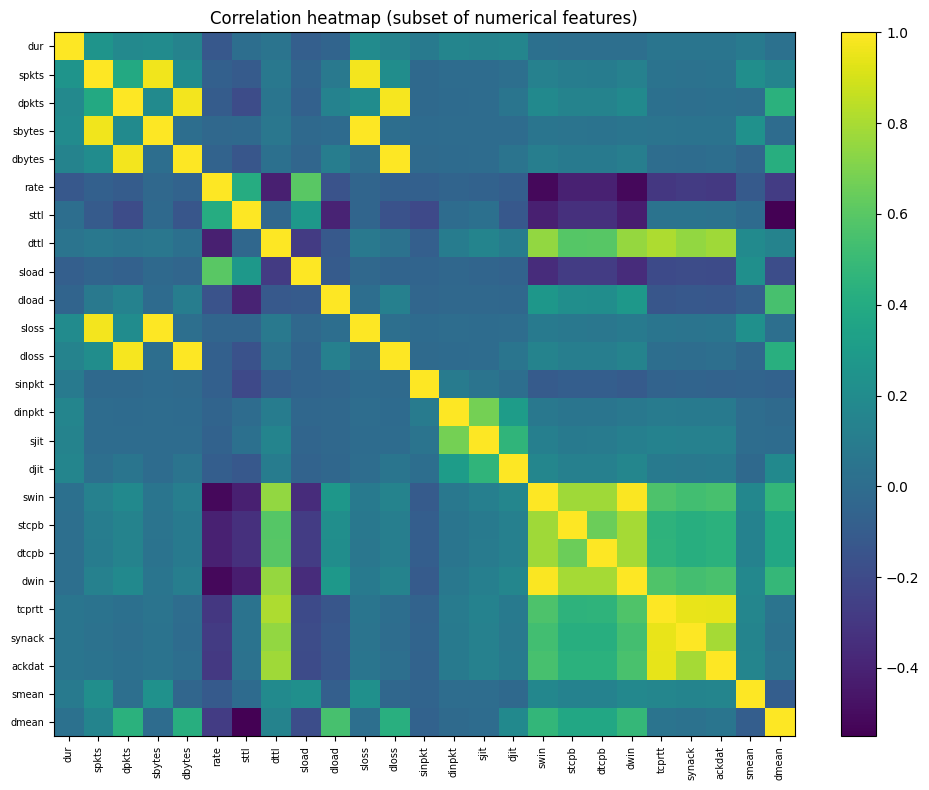

In [7]:

display(train_df[NUMERIC_COLS].describe().T.head(20))

subset_cols = NUMERIC_COLS[:25]
corr = train_df[subset_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Correlation heatmap (subset of numerical features)")
plt.xticks(range(len(subset_cols)), subset_cols, rotation=90, fontsize=7)
plt.yticks(range(len(subset_cols)), subset_cols, fontsize=7)
plt.colorbar()
plt.tight_layout()
plt.show()


## 6) Define dataset branches (supervised vs normal-only)

In [8]:

X_train_sup = train_df[feature_cols].copy()
y_train_sup = train_df[TARGET_BIN].astype(int).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_BIN].astype(int).copy()

train_normal_df = train_df[train_df[TARGET_BIN] == 0].copy()
X_train_norm = train_normal_df[feature_cols].copy()

print("Supervised train:", X_train_sup.shape, "labels:", y_train_sup.shape)
print("Normal-only train:", X_train_norm.shape)
print("Test (mixed):", X_test.shape, "labels:", y_test.shape)


Supervised train: (175341, 42) labels: (175341,)
Normal-only train: (56000, 42)
Test (mixed): (82332, 42) labels: (82332,)


## 7) Preprocessing (ColumnTransformer)

In [9]:

def make_preprocessor():
    cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    num_transformer = StandardScaler()
    return ColumnTransformer(
        transformers=[
            ("cat", cat_transformer, CATEGORICAL_COLS),
            ("num", num_transformer, NUMERIC_COLS),
        ],
        remainder="drop"
    )

pre_sup = make_preprocessor()
pre_norm = make_preprocessor()

pre_sup.fit(X_train_sup)
pre_norm.fit(X_train_norm)

X_train_sup_p = pre_sup.transform(X_train_sup)
X_test_sup_p  = pre_sup.transform(X_test)

X_train_norm_p = pre_norm.transform(X_train_norm)
X_test_norm_p  = pre_norm.transform(X_test)

print("Supervised preprocessed train:", X_train_sup_p.shape, "test:", X_test_sup_p.shape)
print("Normal-only preprocessed train:", X_train_norm_p.shape, "test:", X_test_norm_p.shape)


Supervised preprocessed train: (175341, 194) test: (82332, 194)
Normal-only preprocessed train: (56000, 65) test: (82332, 65)


## 8) Helper: evaluation + plots

In [10]:

def plot_confusion(cm, title):
    plt.figure()
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

def evaluate_binary(y_true, y_pred, y_score=None, title="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n[{title}]")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion(cm, f"{title} — Confusion Matrix")

    metrics = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

    if y_score is not None:
        try:
            roc = roc_auc_score(y_true, y_score)
            ap  = average_precision_score(y_true, y_score)
            metrics["roc_auc"] = roc
            metrics["pr_auc"]  = ap

            fpr, tpr, _ = roc_curve(y_true, y_score)
            plt.figure()
            plt.plot(fpr, tpr)
            plt.title(f"{title} — ROC curve (AUC={roc:.4f})")
            plt.xlabel("FPR"); plt.ylabel("TPR")
            plt.show()

            p, r, _ = precision_recall_curve(y_true, y_score)
            plt.figure()
            plt.plot(r, p)
            plt.title(f"{title} — Precision-Recall curve (AP={ap:.4f})")
            plt.xlabel("Recall"); plt.ylabel("Precision")
            plt.show()
        except Exception as e:
            print("Could not compute ROC/PR curves:", e)

    return metrics


## 9) Task 3 — Supervised baselines (multiple models, no SMOTE yet)


[Logistic Regression (baseline)]
Accuracy : 0.8358
Precision: 0.8028
Recall   : 0.9304
F1-score : 0.8619

Classification report:
              precision    recall  f1-score   support

           0     0.8941    0.7199    0.7976     37000
           1     0.8028    0.9304    0.8619     45332

    accuracy                         0.8358     82332
   macro avg     0.8485    0.8252    0.8298     82332
weighted avg     0.8438    0.8358    0.8330     82332



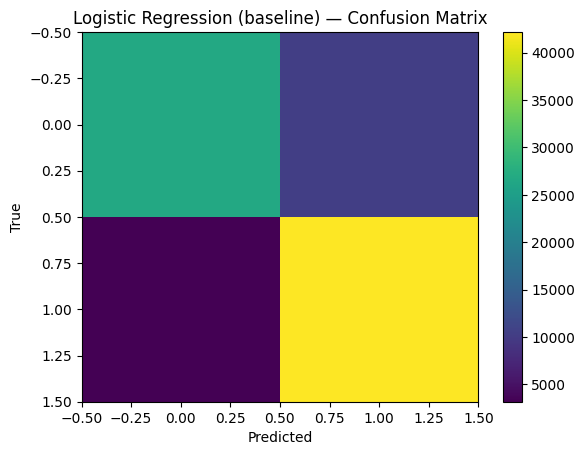

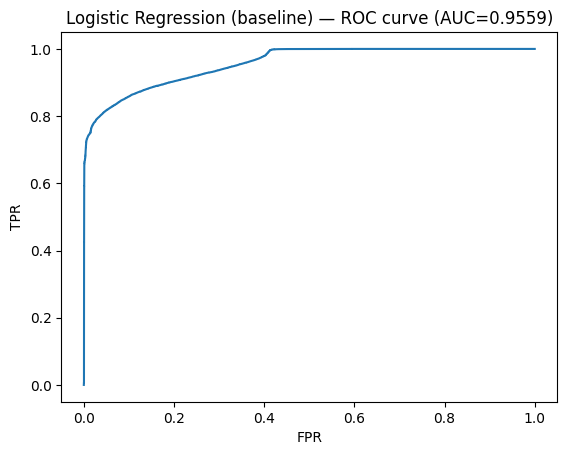

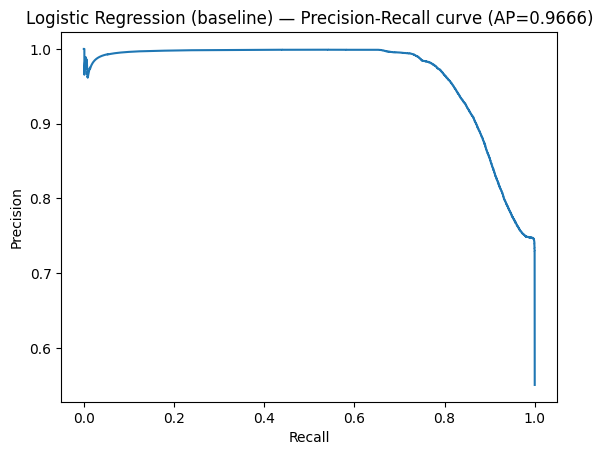


[Random Forest (baseline)]
Accuracy : 0.8696
Precision: 0.8155
Recall   : 0.9865
F1-score : 0.8929

Classification report:
              precision    recall  f1-score   support

           0     0.9777    0.7265    0.8336     37000
           1     0.8155    0.9865    0.8929     45332

    accuracy                         0.8696     82332
   macro avg     0.8966    0.8565    0.8632     82332
weighted avg     0.8884    0.8696    0.8662     82332



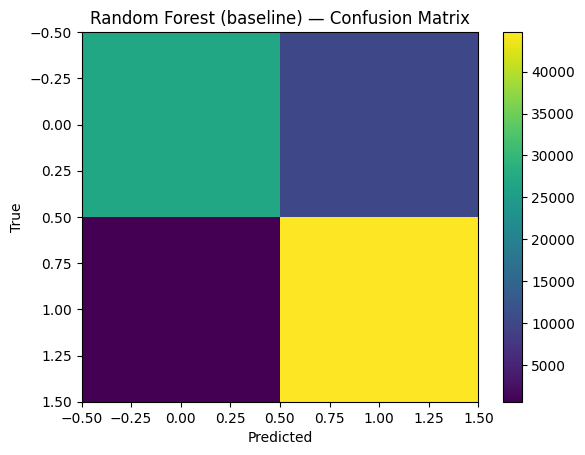

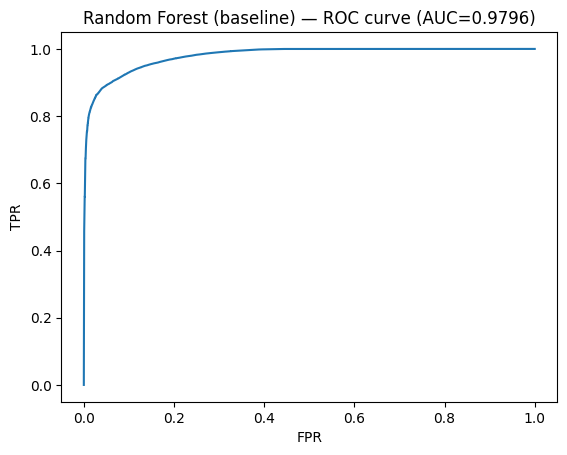

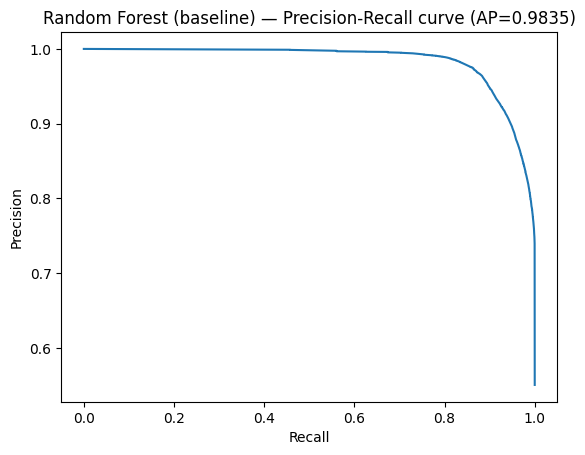


[Gaussian Naive Bayes]
Accuracy : 0.5562
Precision: 0.9998
Recall   : 0.1941
F1-score : 0.3251

Classification report:
              precision    recall  f1-score   support

           0     0.5032    0.9999    0.6695     37000
           1     0.9998    0.1941    0.3251     45332

    accuracy                         0.5562     82332
   macro avg     0.7515    0.5970    0.4973     82332
weighted avg     0.7766    0.5562    0.4798     82332



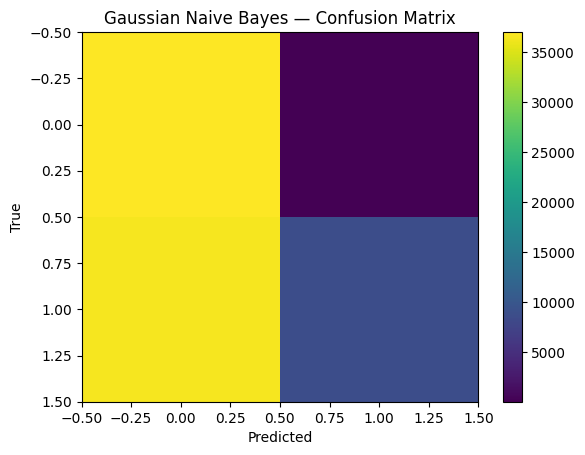

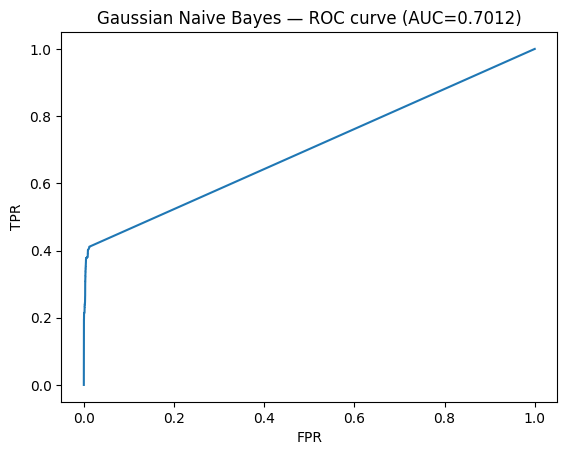

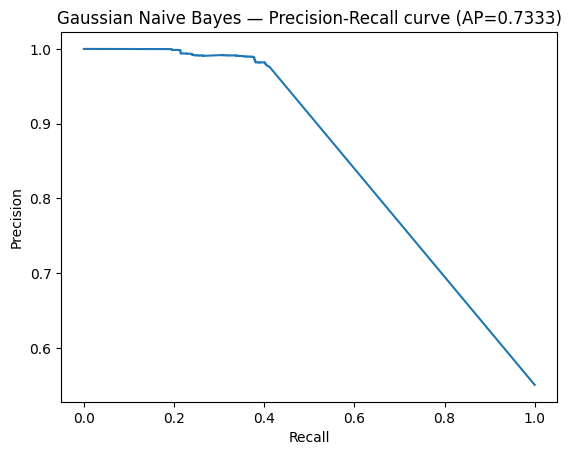


[Decision Tree]
Accuracy : 0.8619
Precision: 0.8180
Recall   : 0.9636
F1-score : 0.8849

Classification report:
              precision    recall  f1-score   support

           0     0.9430    0.7374    0.8276     37000
           1     0.8180    0.9636    0.8849     45332

    accuracy                         0.8619     82332
   macro avg     0.8805    0.8505    0.8562     82332
weighted avg     0.8742    0.8619    0.8591     82332



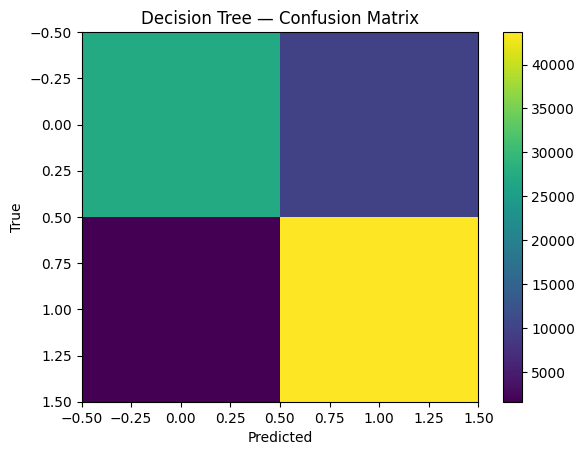

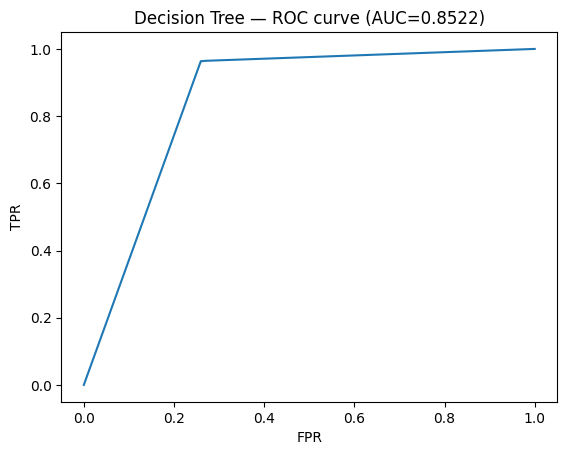

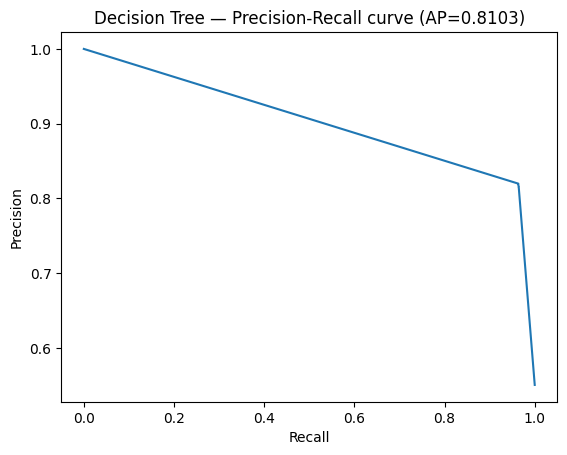


[ExtraTrees]
Accuracy : 0.8626
Precision: 0.8085
Recall   : 0.9833
F1-score : 0.8874

Classification report:
              precision    recall  f1-score   support

           0     0.9721    0.7147    0.8238     37000
           1     0.8085    0.9833    0.8874     45332

    accuracy                         0.8626     82332
   macro avg     0.8903    0.8490    0.8556     82332
weighted avg     0.8821    0.8626    0.8588     82332



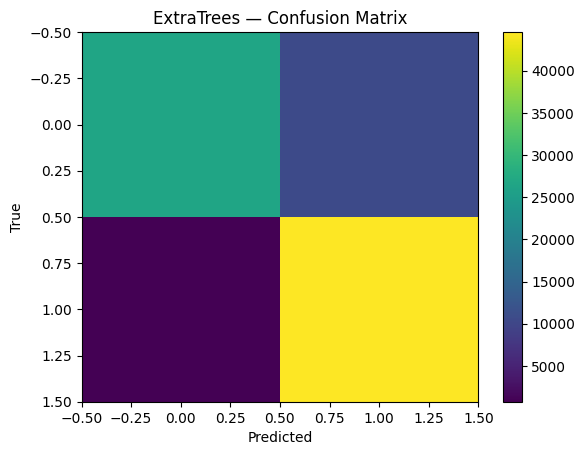

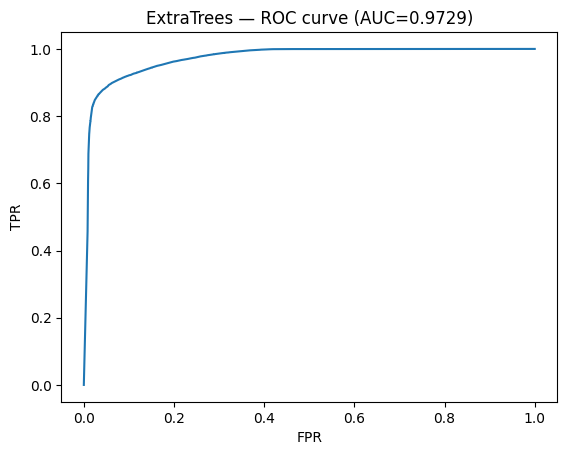

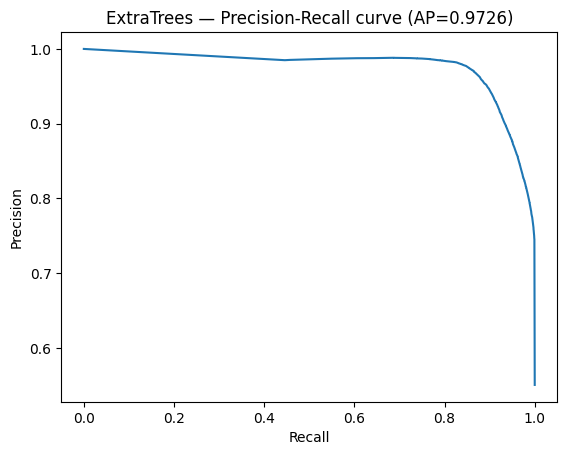


[Gradient Boosting]
Accuracy : 0.8550
Precision: 0.7984
Recall   : 0.9855
F1-score : 0.8822

Classification report:
              precision    recall  f1-score   support

           0     0.9751    0.6952    0.8117     37000
           1     0.7984    0.9855    0.8822     45332

    accuracy                         0.8550     82332
   macro avg     0.8868    0.8403    0.8469     82332
weighted avg     0.8778    0.8550    0.8505     82332



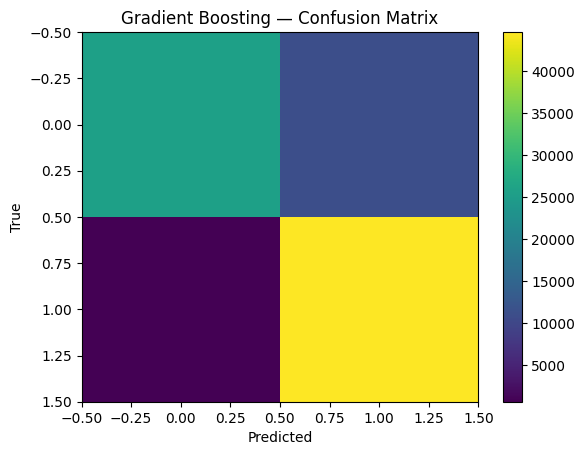

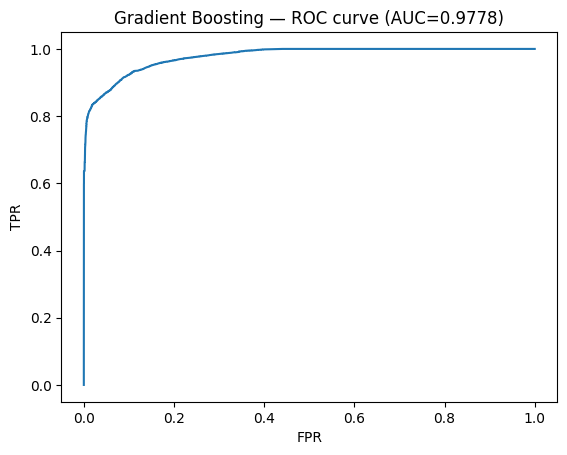

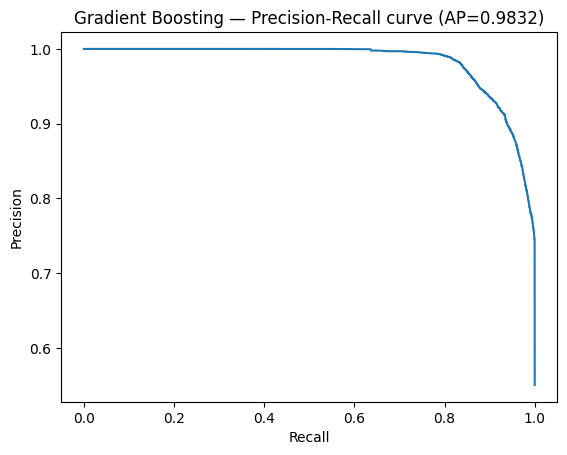


[Linear SVM (calibrated)]
Accuracy : 0.8085
Precision: 0.7455
Recall   : 0.9904
F1-score : 0.8507

Classification report:
              precision    recall  f1-score   support

           0     0.9803    0.5857    0.7333     37000
           1     0.7455    0.9904    0.8507     45332

    accuracy                         0.8085     82332
   macro avg     0.8629    0.7881    0.7920     82332
weighted avg     0.8510    0.8085    0.7979     82332



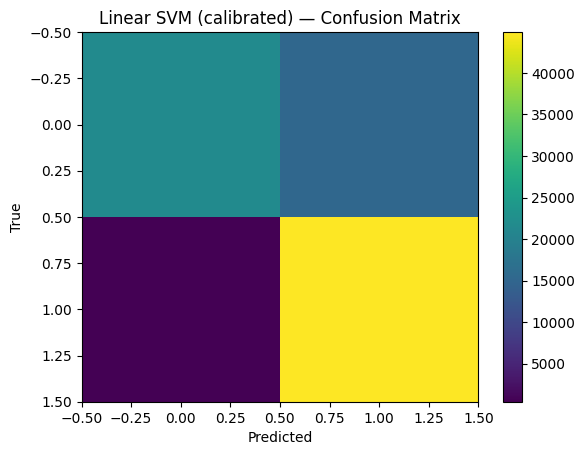

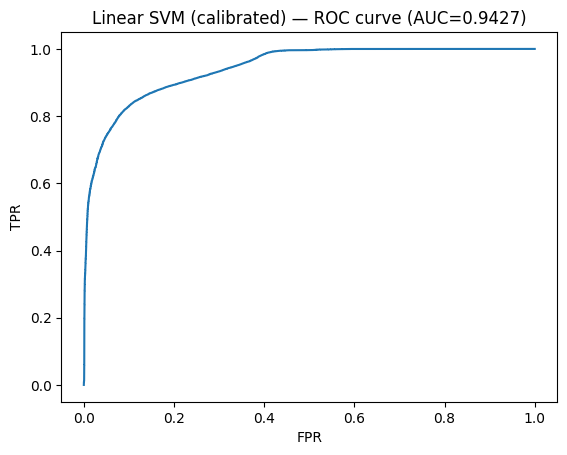

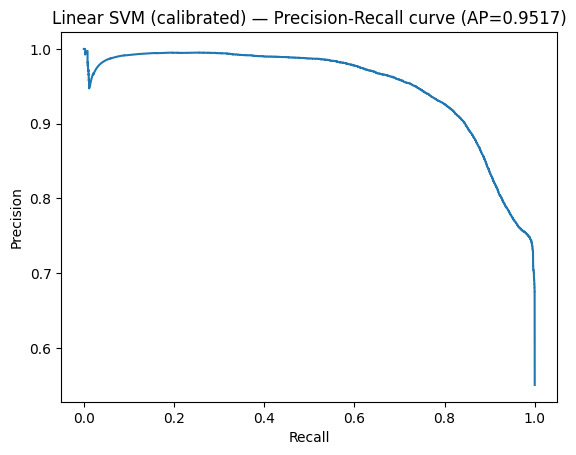

In [11]:

metrics_store = {}

# 9.1 Logistic Regression (balanced)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr.fit(X_train_sup_p, y_train_sup)
lr_proba = lr.predict_proba(X_test_sup_p)[:, 1]
lr_pred  = (lr_proba >= 0.5).astype(int)
metrics_store["LR_baseline"] = evaluate_binary(y_test, lr_pred, lr_proba, title="Logistic Regression (baseline)")

# 9.2 Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sup_p, y_train_sup)
rf_proba = rf.predict_proba(X_test_sup_p)[:, 1]
rf_pred  = (rf_proba >= 0.5).astype(int)
metrics_store["RF_baseline"] = evaluate_binary(y_test, rf_pred, rf_proba, title="Random Forest (baseline)")

# 9.3 Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_sup_p, y_train_sup)
gnb_proba = gnb.predict_proba(X_test_sup_p)[:, 1]
gnb_pred  = (gnb_proba >= 0.5).astype(int)
metrics_store["GaussianNB"] = evaluate_binary(y_test, gnb_pred, gnb_proba, title="Gaussian Naive Bayes")

# 9.4 Decision Tree
dt = DecisionTreeClassifier(random_state=SEED, class_weight="balanced", max_depth=None)
dt.fit(X_train_sup_p, y_train_sup)
dt_proba = dt.predict_proba(X_test_sup_p)[:, 1]
dt_pred  = (dt_proba >= 0.5).astype(int)
metrics_store["DecisionTree"] = evaluate_binary(y_test, dt_pred, dt_proba, title="Decision Tree")

# 9.5 ExtraTrees (often strong on tabular)
et = ExtraTreesClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)
et.fit(X_train_sup_p, y_train_sup)
et_proba = et.predict_proba(X_test_sup_p)[:, 1]
et_pred  = (et_proba >= 0.5).astype(int)
metrics_store["ExtraTrees"] = evaluate_binary(y_test, et_pred, et_proba, title="ExtraTrees")

# 9.6 Gradient Boosting (sklearn)
gb = GradientBoostingClassifier(random_state=SEED)
gb.fit(X_train_sup_p, y_train_sup)
gb_proba = gb.predict_proba(X_test_sup_p)[:, 1]
gb_pred  = (gb_proba >= 0.5).astype(int)
metrics_store["GradBoost"] = evaluate_binary(y_test, gb_pred, gb_proba, title="Gradient Boosting")

# 9.7 Linear SVM (LinearSVC) + calibration to get probabilities
# Calibration adds runtime but makes curves/thresholding easier.
svm_base = LinearSVC(random_state=SEED, class_weight="balanced")
svm = CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)
svm.fit(X_train_sup_p, y_train_sup)
svm_proba = svm.predict_proba(X_test_sup_p)[:, 1]
svm_pred  = (svm_proba >= 0.5).astype(int)
metrics_store["LinearSVM_calib"] = evaluate_binary(y_test, svm_pred, svm_proba, title="Linear SVM (calibrated)")


## 10) Task 3 — Supervised with SMOTE (apply only to training, via pipeline)


[Random Forest + SMOTE]
Accuracy : 0.8840
Precision: 0.8367
Recall   : 0.9808
F1-score : 0.9030

Classification report:
              precision    recall  f1-score   support

           0     0.9702    0.7654    0.8557     37000
           1     0.8367    0.9808    0.9030     45332

    accuracy                         0.8840     82332
   macro avg     0.9035    0.8731    0.8794     82332
weighted avg     0.8967    0.8840    0.8818     82332



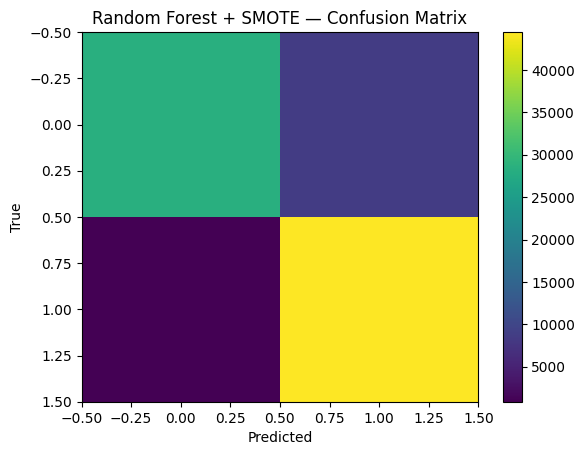

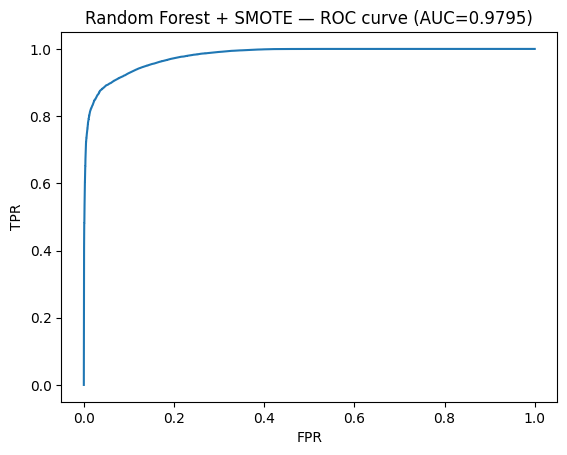

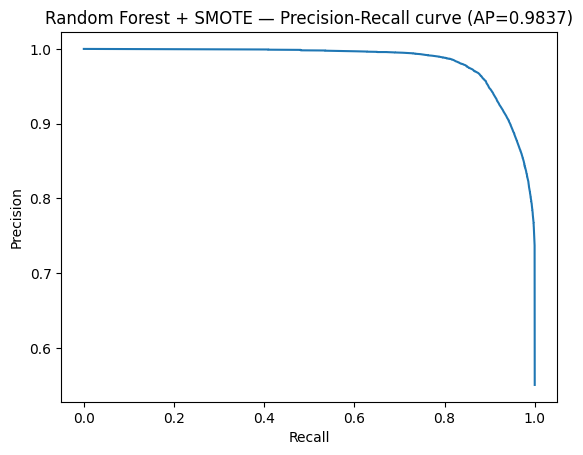


[Logistic Regression + SMOTE]
Accuracy : 0.8379
Precision: 0.8048
Recall   : 0.9315
F1-score : 0.8635

Classification report:
              precision    recall  f1-score   support

           0     0.8960    0.7232    0.8004     37000
           1     0.8048    0.9315    0.8635     45332

    accuracy                         0.8379     82332
   macro avg     0.8504    0.8274    0.8320     82332
weighted avg     0.8458    0.8379    0.8352     82332



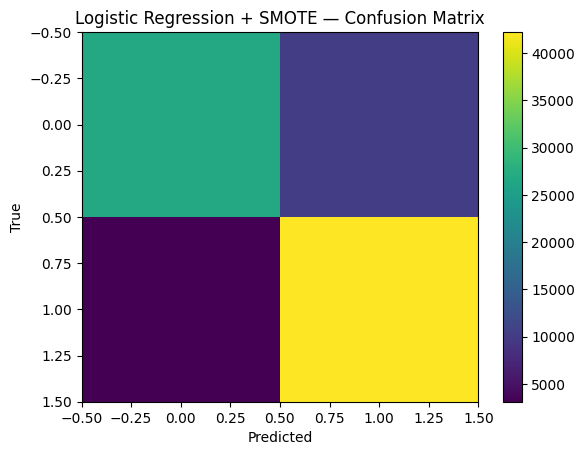

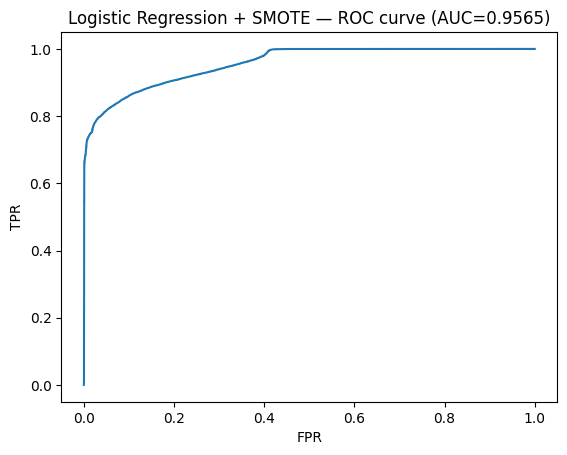

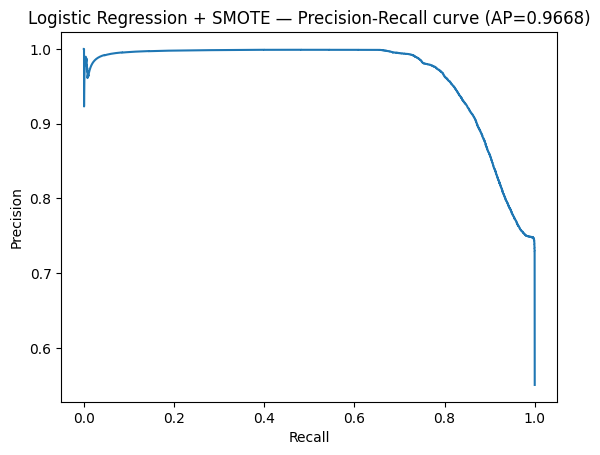

In [12]:

smote = SMOTE(random_state=SEED)

# We'll SMOTE only for selected models (it may not help all of them equally)
rf_smote = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", smote),
    ("model", RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1))
])

lr_smote = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", smote),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED))
])

rf_smote.fit(X_train_sup, y_train_sup)
rf_smote_proba = rf_smote.predict_proba(X_test)[:, 1]
rf_smote_pred  = (rf_smote_proba >= 0.5).astype(int)
metrics_store["RF_SMOTE"] = evaluate_binary(y_test, rf_smote_pred, rf_smote_proba, title="Random Forest + SMOTE")

lr_smote.fit(X_train_sup, y_train_sup)
lr_smote_proba = lr_smote.predict_proba(X_test)[:, 1]
lr_smote_pred  = (lr_smote_proba >= 0.5).astype(int)
metrics_store["LR_SMOTE"] = evaluate_binary(y_test, lr_smote_pred, lr_smote_proba, title="Logistic Regression + SMOTE")


## 11) Task 5 — Hyperparameter tuning example (Supervised): RF + SMOTE

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 25}
Best CV F1: 0.9689545749579894

[RF + SMOTE (tuned)]
Accuracy : 0.8780
Precision: 0.8314
Recall   : 0.9765
F1-score : 0.8981

Classification report:
              precision    recall  f1-score   support

           0     0.9634    0.7573    0.8480     37000
           1     0.8314    0.9765    0.8981     45332

    accuracy                         0.8780     82332
   macro avg     0.8974    0.8669    0.8731     82332
weighted avg     0.8907    0.8780    0.8756     82332



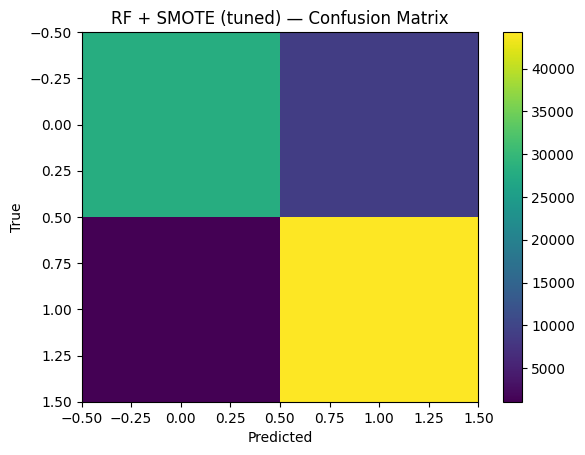

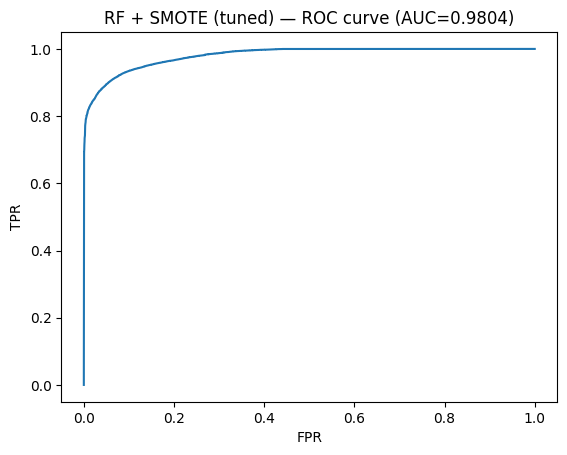

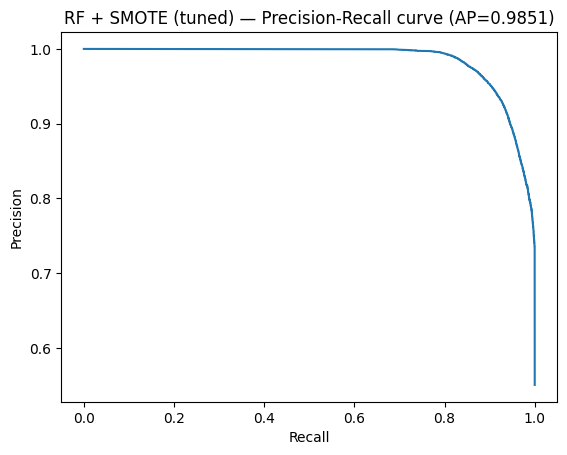

In [13]:

rf_smote_tune = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", SMOTE(random_state=SEED)),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 15, 25, 35],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    rf_smote_tune,
    param_distributions=param_dist,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_sup, y_train_sup)
print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

best_model = search.best_estimator_
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred  = (best_proba >= 0.5).astype(int)
metrics_store["RF_SMOTE_tuned"] = evaluate_binary(y_test, best_pred, best_proba, title="RF + SMOTE (tuned)")


## 12) Task 2 — Unsupervised anomaly detection (multiple methods)
Train on **normal-only**, evaluate on mixed TEST.

Threshold strategy: start with **95th percentile** on train-normal scores (controls FP).

IsolationForest threshold (95th): 0.5102265453385405

[Isolation Forest (p95 threshold)]
Accuracy : 0.5936
Precision: 0.8585
Recall   : 0.3135
F1-score : 0.4593

Classification report:
              precision    recall  f1-score   support

           0     0.5269    0.9367    0.6744     37000
           1     0.8585    0.3135    0.4593     45332

    accuracy                         0.5936     82332
   macro avg     0.6927    0.6251    0.5668     82332
weighted avg     0.7095    0.5936    0.5560     82332



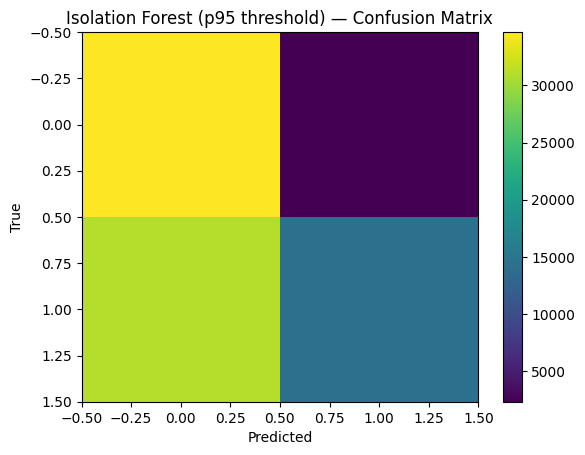

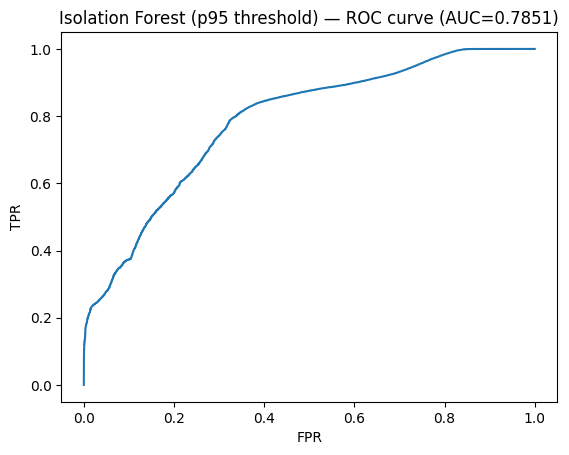

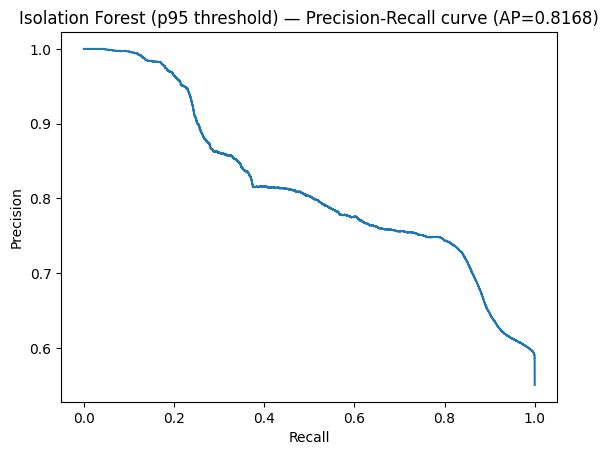

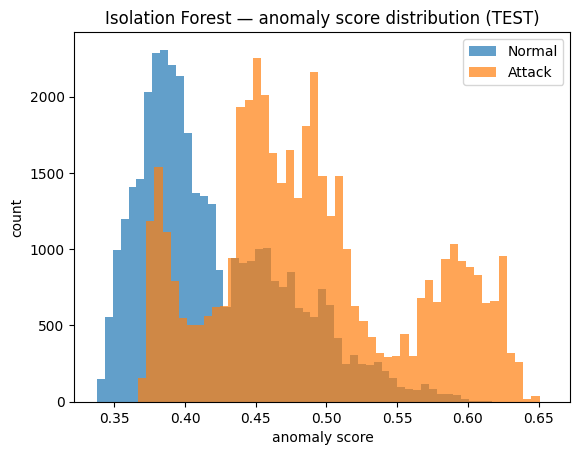

OCSVM threshold (95th): 0.0002631129365511242

[One-Class SVM (p95 threshold)]
Accuracy : 0.5834
Precision: 0.8170
Recall   : 0.3137
F1-score : 0.4533

Classification report:
              precision    recall  f1-score   support

           0     0.5208    0.9139    0.6635     37000
           1     0.8170    0.3137    0.4533     45332

    accuracy                         0.5834     82332
   macro avg     0.6689    0.6138    0.5584     82332
weighted avg     0.6839    0.5834    0.5478     82332



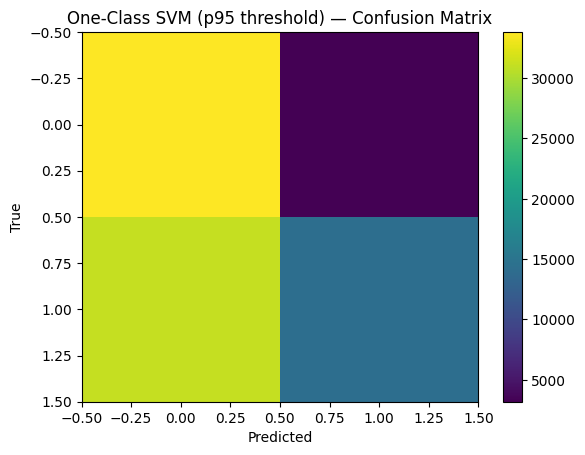

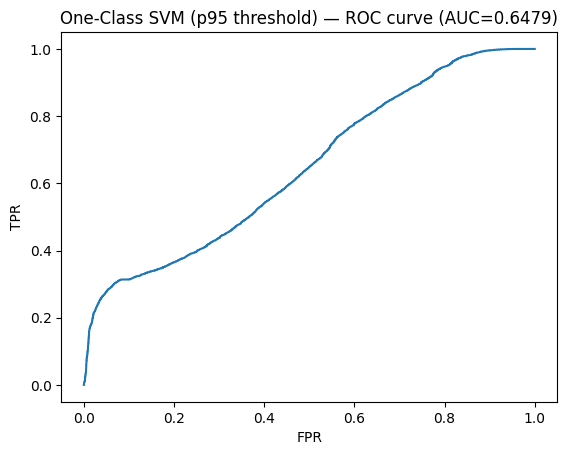

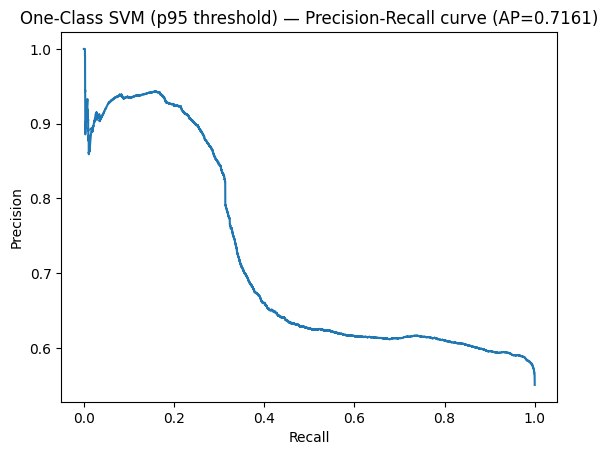

LOF threshold (95th): -0.12784637443930713

[LOF novelty (p95 threshold)]
Accuracy : 0.8163
Precision: 0.8873
Recall   : 0.7633
F1-score : 0.8207

Classification report:
              precision    recall  f1-score   support

           0     0.7524    0.8812    0.8117     37000
           1     0.8873    0.7633    0.8207     45332

    accuracy                         0.8163     82332
   macro avg     0.8198    0.8223    0.8162     82332
weighted avg     0.8267    0.8163    0.8166     82332



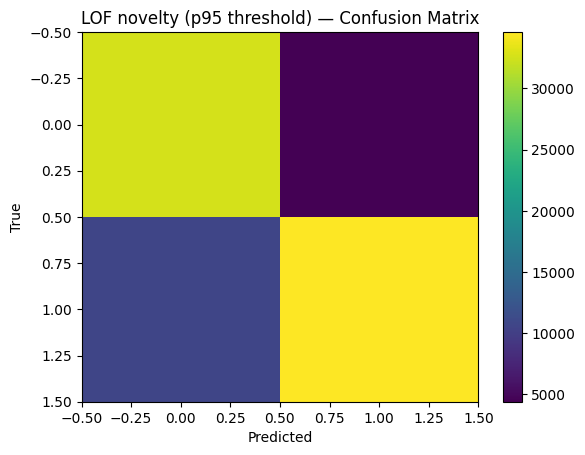

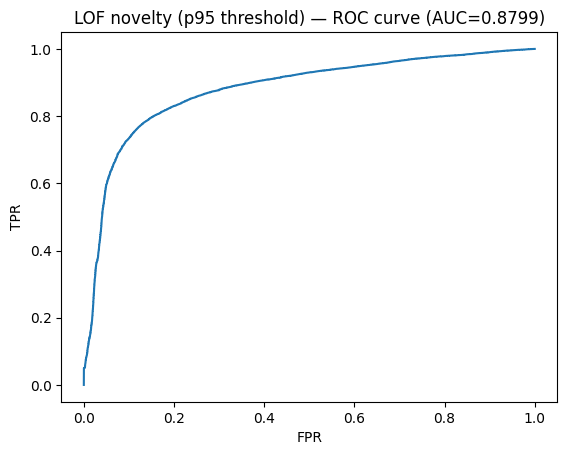

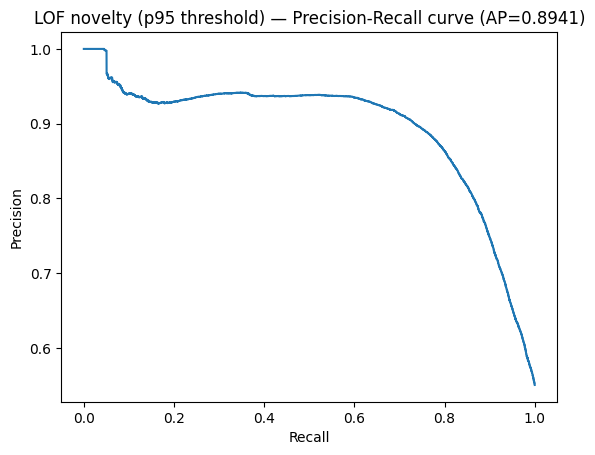

kNN threshold (95th): 1.8633563701797857

[kNN anomaly (k=10, p95 threshold)]
Accuracy : 0.7559
Precision: 0.8775
Recall   : 0.6470
F1-score : 0.7448

Classification report:
              precision    recall  f1-score   support

           0     0.6728    0.8894    0.7661     37000
           1     0.8775    0.6470    0.7448     45332

    accuracy                         0.7559     82332
   macro avg     0.7752    0.7682    0.7555     82332
weighted avg     0.7855    0.7559    0.7544     82332



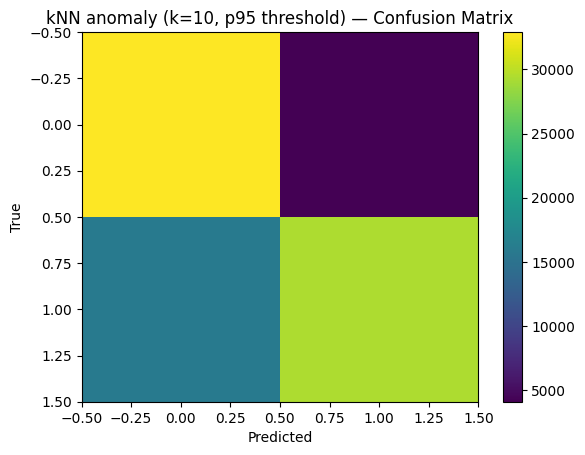

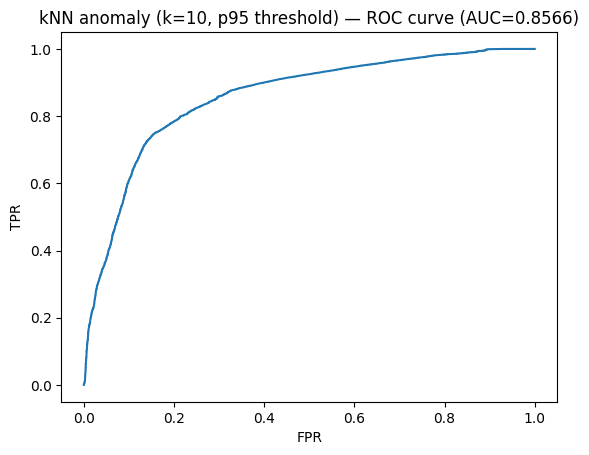

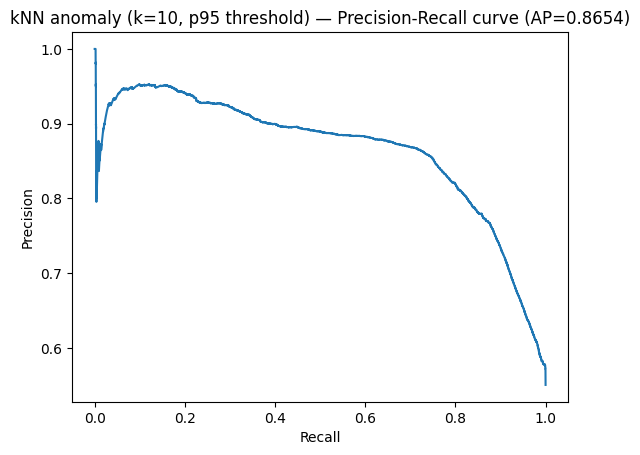

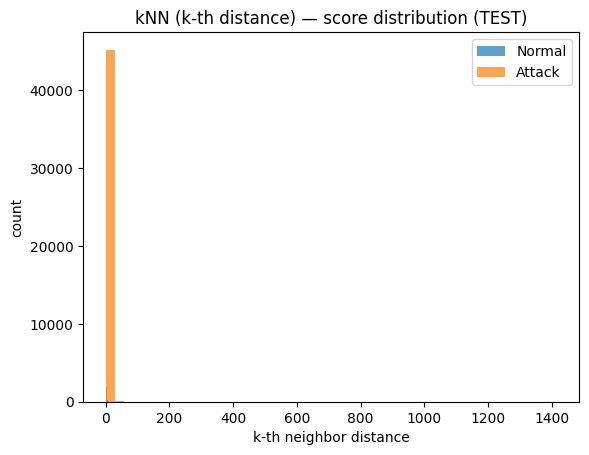

PCA threshold (95th): 0.08337662103903702

[PCA reconstruction error (p95 threshold)]
Accuracy : 0.5406
Precision: 0.7524
Recall   : 0.2468
F1-score : 0.3717

Classification report:
              precision    recall  f1-score   support

           0     0.4939    0.9005    0.6379     37000
           1     0.7524    0.2468    0.3717     45332

    accuracy                         0.5406     82332
   macro avg     0.6231    0.5737    0.5048     82332
weighted avg     0.6362    0.5406    0.4913     82332



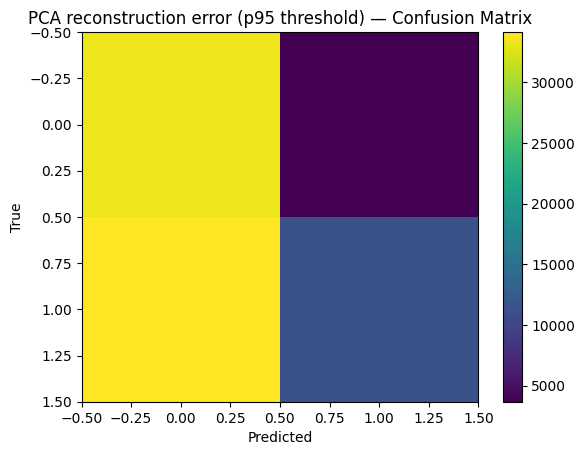

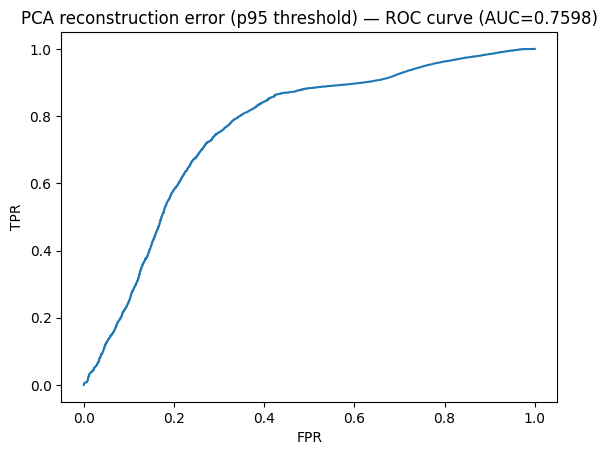

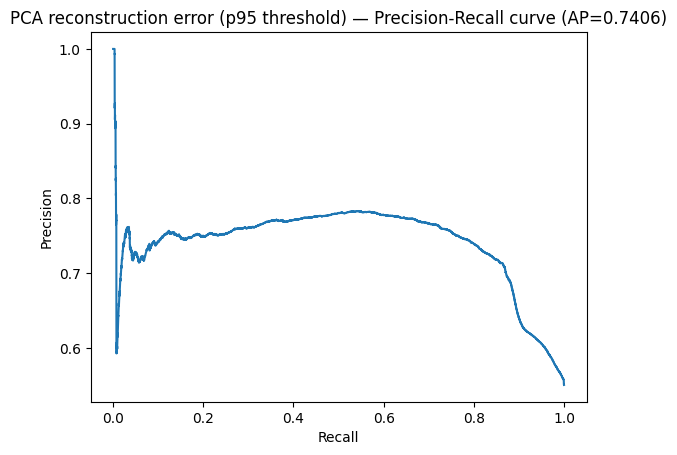

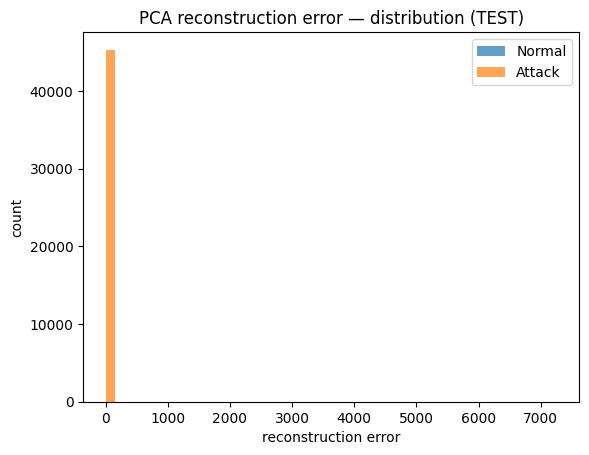

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


EllipticEnvelope threshold (95th): -9.257164492737502e-07

[EllipticEnvelope (p95 threshold)]
Accuracy : 0.7388
Precision: 0.8870
Recall   : 0.6023
F1-score : 0.7174

Classification report:
              precision    recall  f1-score   support

           0     0.6503    0.9060    0.7571     37000
           1     0.8870    0.6023    0.7174     45332

    accuracy                         0.7388     82332
   macro avg     0.7686    0.7541    0.7373     82332
weighted avg     0.7806    0.7388    0.7353     82332



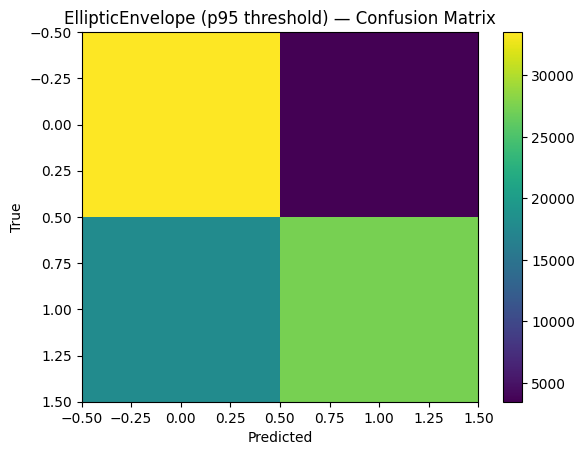

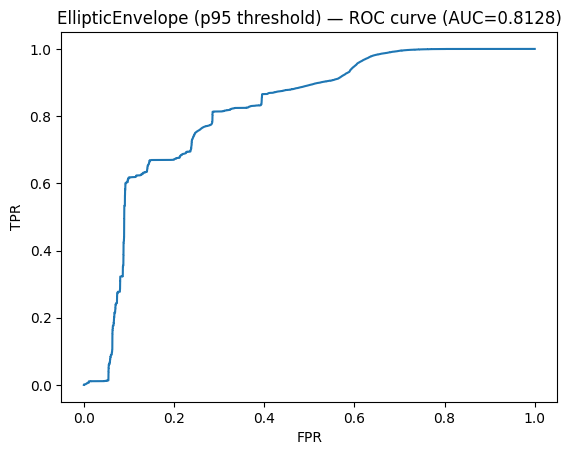

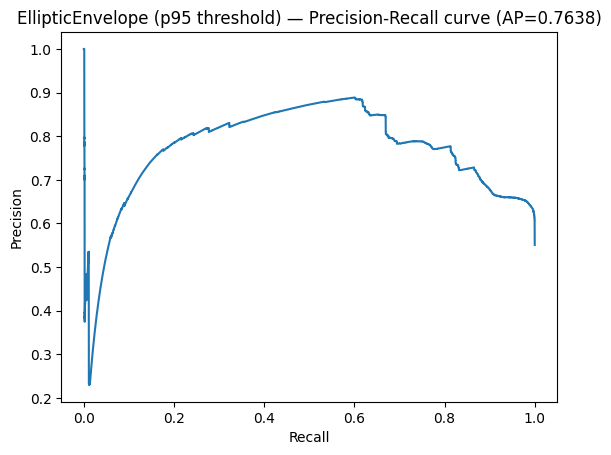

In [14]:

# We'll store anomaly metrics separately too (still binary metrics vs label)
anom_metrics = {}

def percentile_threshold(train_scores, pct=95):
    return float(np.percentile(train_scores, pct))

# 12.1 Isolation Forest
iso = IsolationForest(n_estimators=600, contamination="auto", random_state=SEED, n_jobs=-1)
iso.fit(X_train_norm_p)
score_test = -iso.score_samples(X_test_norm_p)
score_train = -iso.score_samples(X_train_norm_p)
thr = percentile_threshold(score_train, 95)
print("IsolationForest threshold (95th):", thr)
pred = (score_test >= thr).astype(int)
anom_metrics["IsolationForest"] = evaluate_binary(y_test, pred, score_test, title="Isolation Forest (p95 threshold)")

plt.figure()
plt.hist(score_test[y_test==0], bins=50, alpha=0.7, label="Normal")
plt.hist(score_test[y_test==1], bins=50, alpha=0.7, label="Attack")
plt.title("Isolation Forest — anomaly score distribution (TEST)")
plt.xlabel("anomaly score"); plt.ylabel("count")
plt.legend(); plt.show()

# 12.2 One-Class SVM
ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_train_norm_p)
oc_score_test = -ocsvm.decision_function(X_test_norm_p).ravel()
oc_score_train = -ocsvm.decision_function(X_train_norm_p).ravel()
thr = percentile_threshold(oc_score_train, 95)
print("OCSVM threshold (95th):", thr)
pred = (oc_score_test >= thr).astype(int)
anom_metrics["OneClassSVM"] = evaluate_binary(y_test, pred, oc_score_test, title="One-Class SVM (p95 threshold)")

# 12.3 LOF (novelty)
lof = LocalOutlierFactor(n_neighbors=35, novelty=True)
lof.fit(X_train_norm_p)
lof_score_test = -lof.decision_function(X_test_norm_p).ravel()
lof_score_train = -lof.decision_function(X_train_norm_p).ravel()
thr = percentile_threshold(lof_score_train, 95)
print("LOF threshold (95th):", thr)
pred = (lof_score_test >= thr).astype(int)
anom_metrics["LOF_novelty"] = evaluate_binary(y_test, pred, lof_score_test, title="LOF novelty (p95 threshold)")

# 12.4 kNN distance anomaly score (common baseline for network anomalies)
# Score = distance to k-th nearest neighbor among normal-only points.
k = 10
nn = NearestNeighbors(n_neighbors=k, algorithm="auto", n_jobs=-1)
nn.fit(X_train_norm_p)
dists_test, _ = nn.kneighbors(X_test_norm_p, return_distance=True)
dists_train, _ = nn.kneighbors(X_train_norm_p, return_distance=True)

knn_score_test = dists_test[:, -1]   # k-th NN distance
knn_score_train = dists_train[:, -1]
thr = percentile_threshold(knn_score_train, 95)
print("kNN threshold (95th):", thr)
pred = (knn_score_test >= thr).astype(int)
anom_metrics["kNN_kthDist"] = evaluate_binary(y_test, pred, knn_score_test, title=f"kNN anomaly (k={k}, p95 threshold)")

plt.figure()
plt.hist(knn_score_test[y_test==0], bins=50, alpha=0.7, label="Normal")
plt.hist(knn_score_test[y_test==1], bins=50, alpha=0.7, label="Attack")
plt.title("kNN (k-th distance) — score distribution (TEST)")
plt.xlabel("k-th neighbor distance"); plt.ylabel("count")
plt.legend(); plt.show()

# 12.5 PCA reconstruction error (lightweight AE-like baseline)
pca = PCA(n_components=0.95, random_state=SEED)  # keep 95% variance
pca.fit(X_train_norm_p)

X_train_proj = pca.inverse_transform(pca.transform(X_train_norm_p))
X_test_proj  = pca.inverse_transform(pca.transform(X_test_norm_p))

pca_train_err = np.mean((X_train_norm_p - X_train_proj) ** 2, axis=1)
pca_test_err  = np.mean((X_test_norm_p - X_test_proj) ** 2, axis=1)

thr = percentile_threshold(pca_train_err, 95)
print("PCA threshold (95th):", thr)
pred = (pca_test_err >= thr).astype(int)
anom_metrics["PCA_recon"] = evaluate_binary(y_test, pred, pca_test_err, title="PCA reconstruction error (p95 threshold)")

plt.figure()
plt.hist(pca_test_err[y_test==0], bins=50, alpha=0.7, label="Normal")
plt.hist(pca_test_err[y_test==1], bins=50, alpha=0.7, label="Attack")
plt.title("PCA reconstruction error — distribution (TEST)")
plt.xlabel("reconstruction error"); plt.ylabel("count")
plt.legend(); plt.show()

# 12.6 EllipticEnvelope (robust covariance / Gaussian assumption baseline)
# Note: may be sensitive in high dimensions; still a useful classical baseline.
ee = EllipticEnvelope(contamination=0.05, random_state=SEED)
ee.fit(X_train_norm_p)

# decision_function: larger = more normal; invert for anomaly score
ee_test_score = -ee.decision_function(X_test_norm_p).ravel()
ee_train_score = -ee.decision_function(X_train_norm_p).ravel()

thr = percentile_threshold(ee_train_score, 95)
print("EllipticEnvelope threshold (95th):", thr)
pred = (ee_test_score >= thr).astype(int)
anom_metrics["EllipticEnvelope"] = evaluate_binary(y_test, pred, ee_test_score, title="EllipticEnvelope (p95 threshold)")


## 13) Task 5 — Tuning example (Unsupervised): Isolation Forest + threshold on validation

In [15]:

# Mixed validation split from TRAIN set (for tuning only)
X_tr, X_val, y_tr, y_val = train_test_split(
    train_df[feature_cols], train_df[TARGET_BIN].astype(int),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df[TARGET_BIN].astype(int)
)

X_tr_norm = X_tr[y_tr == 0]

pre_tmp = make_preprocessor()
pre_tmp.fit(X_tr_norm)

X_tr_norm_p = pre_tmp.transform(X_tr_norm)
X_val_p = pre_tmp.transform(X_val)

grid = []
for n_estimators in [200, 400, 800]:
    for max_samples in ["auto", 0.7, 1.0]:
        iso_tmp = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            random_state=SEED,
            n_jobs=-1
        )
        iso_tmp.fit(X_tr_norm_p)

        val_score = -iso_tmp.score_samples(X_val_p)
        tr_score  = -iso_tmp.score_samples(X_tr_norm_p)

        # threshold candidates from normal-only training distribution
        candidates = np.percentile(tr_score, [90, 93, 95, 97, 99])
        best = None
        for thr in candidates:
            pred = (val_score >= thr).astype(int)
            f1 = f1_score(y_val, pred, zero_division=0)
            if best is None or f1 > best["f1"]:
                best = {"thr": float(thr), "f1": float(f1)}

        grid.append({
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "best_thr": best["thr"],
            "val_f1": best["f1"],
        })

grid_df = pd.DataFrame(grid).sort_values("val_f1", ascending=False)
display(grid_df.head(10))


,n_estimators,max_samples,best_thr,val_f1
5,400,1.0,0.402508,0.812854
8,800,1.0,0.402479,0.812708
7,800,0.7,0.408951,0.809320
4,400,0.7,0.407864,0.808951
2,200,1.0,0.403531,0.805983
1,200,0.7,0.409334,0.803123
6,800,auto,0.473364,0.620642
3,400,auto,0.477430,0.620516
0,200,auto,0.480161,0.620348


## 14) Task 4 — Deep Learning Autoencoder (normal-only training)

Autoencoder input dimension: 63


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 63)             │         8,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,087 (144.87 KB)

 Trainable params: 37,087 (144.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.4945 - val_loss: 0.1086
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0990 - val_loss: 0.0503
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0541 - val_loss: 0.0332
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0393 - val_loss: 0.0255
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0321 - val_loss: 0.0205
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0275 - val_loss: 0.0174
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0243 - val_loss: 0.0152
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0219 - val_loss: 0.0129
Epoch 9/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0195 - val_loss: 0.0120
Epoch 10/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0184 - val_loss: 0.0106
Epoch 11/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0169 - val_loss: 0.0106
Epoch 12/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0162 - val_l

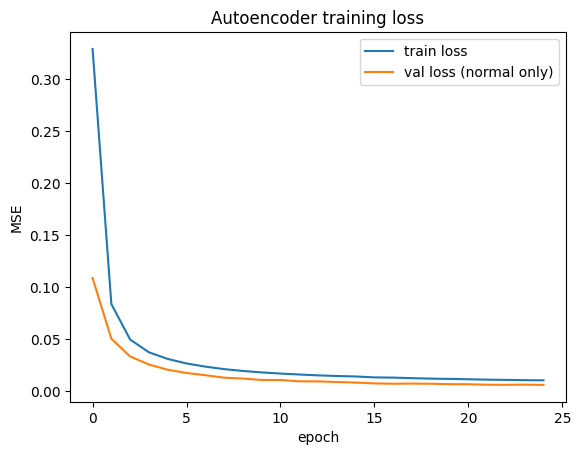

Best threshold on validation: {'thr': 0.01007392900064587, 'f1': 0.8695907622082119}

[Autoencoder (threshold tuned on val)]
Accuracy : 0.8413
Precision: 0.8638
Recall   : 0.8451
F1-score : 0.8543

Classification report:
              precision    recall  f1-score   support

           0     0.8151    0.8368    0.8258     37000
           1     0.8638    0.8451    0.8543     45332

    accuracy                         0.8413     82332
   macro avg     0.8395    0.8409    0.8401     82332
weighted avg     0.8419    0.8413    0.8415     82332



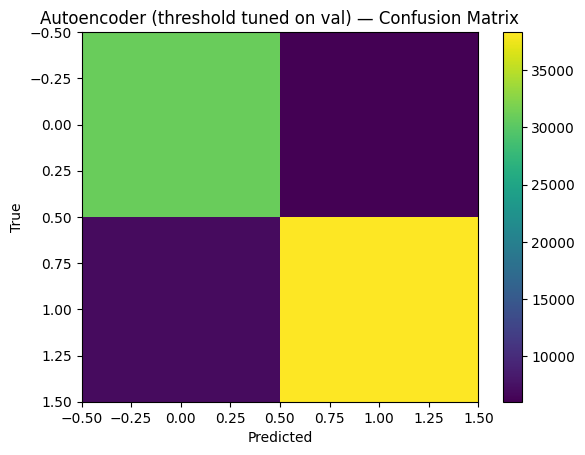

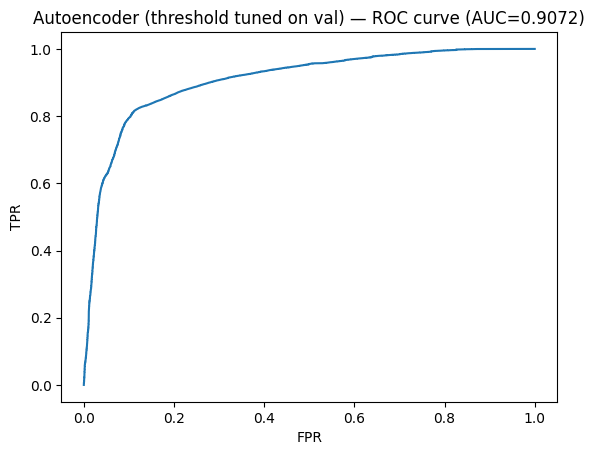

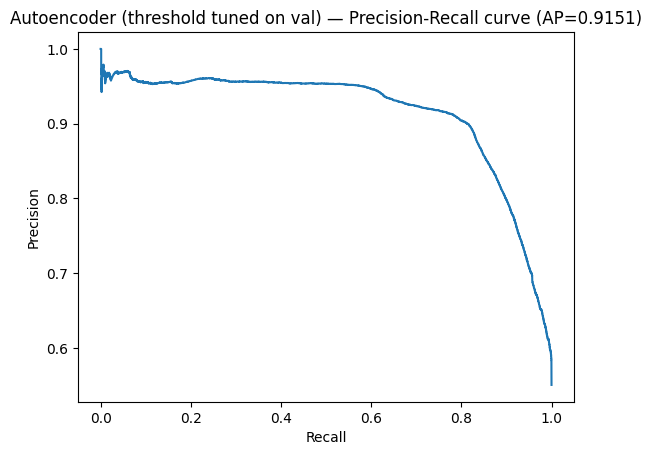

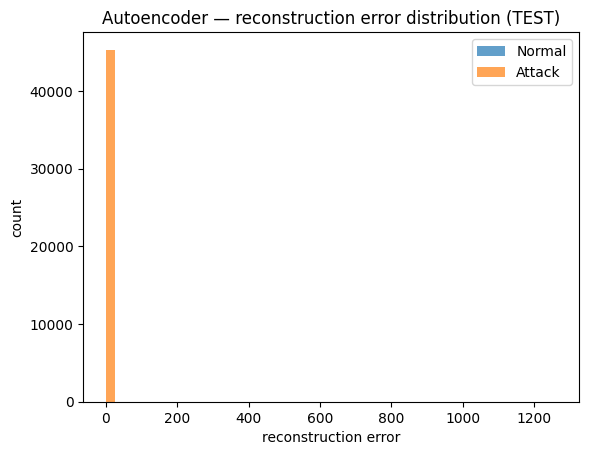

In [16]:

# Validation split for threshold selection
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    train_df[feature_cols], train_df[TARGET_BIN].astype(int),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df[TARGET_BIN].astype(int)
)

X_tr2_norm = X_tr2[y_tr2 == 0]

pre_ae = make_preprocessor()
pre_ae.fit(X_tr2_norm)

X_tr2_norm_p = pre_ae.transform(X_tr2_norm).astype("float32")
X_val2_p = pre_ae.transform(X_val2).astype("float32")
X_test_ae_p = pre_ae.transform(X_test).astype("float32")

input_dim = X_tr2_norm_p.shape[1]
print("Autoencoder input dimension:", input_dim)

def build_autoencoder(input_dim, bottleneck=32, dropout=0.1):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    z = layers.Dense(bottleneck, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(input_dim, activation="linear")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

ae = build_autoencoder(input_dim, bottleneck=32, dropout=0.1)
ae.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

history = ae.fit(
    X_tr2_norm_p, X_tr2_norm_p,
    epochs=25,
    batch_size=512,
    validation_data=(X_val2_p[y_val2==0], X_val2_p[y_val2==0]),
    callbacks=callbacks,
    verbose=1
)

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss (normal only)")
plt.title("Autoencoder training loss")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

err_train_norm = recon_error(ae, X_tr2_norm_p)
err_val = recon_error(ae, X_val2_p)
err_test = recon_error(ae, X_test_ae_p)

# Choose threshold to maximize F1 on mixed validation
cands = np.percentile(err_train_norm, [90, 93, 95, 97, 99, 99.5])
best = None
for thr in cands:
    pred = (err_val >= thr).astype(int)
    f1 = f1_score(y_val2, pred, zero_division=0)
    if best is None or f1 > best["f1"]:
        best = {"thr": float(thr), "f1": float(f1)}

print("Best threshold on validation:", best)

y_pred_ae = (err_test >= best["thr"]).astype(int)
anom_metrics["Autoencoder"] = evaluate_binary(y_test, y_pred_ae, err_test, title="Autoencoder (threshold tuned on val)")

plt.figure()
plt.hist(err_test[y_test==0], bins=50, alpha=0.7, label="Normal")
plt.hist(err_test[y_test==1], bins=50, alpha=0.7, label="Attack")
plt.title("Autoencoder — reconstruction error distribution (TEST)")
plt.xlabel("reconstruction error"); plt.ylabel("count")
plt.legend(); plt.show()


## 15) Model comparison table (Supervised vs Anomaly models)

,accuracy,precision,recall,f1,roc_auc,pr_auc
RF_SMOTE,0.884031,0.836683,0.980830,0.903040,0.979539,0.983660
RF_SMOTE_tuned,0.877994,0.831352,0.976507,0.898102,0.980360,0.985109
RF_baseline,0.869650,0.815486,0.986455,0.892860,0.979563,0.983508
ExtraTrees,0.862593,0.808540,0.983279,0.887389,0.972893,0.972593
DecisionTree,0.861949,0.818034,0.963624,0.884880,0.852248,0.810264
GradBoost,0.855038,0.798427,0.985529,0.882167,0.977780,0.983166
LR_SMOTE,0.837912,0.804830,0.931505,0.863547,0.956479,0.966786
LR_baseline,0.835835,0.802779,0.930424,0.861901,0.955917,0.966616
Autoencoder,0.841350,0.863843,0.845054,0.854346,0.907221,0.915134
LinearSVM_calib,0.808543,0.745488,0.990404,0.850668,0.942702,0.951714


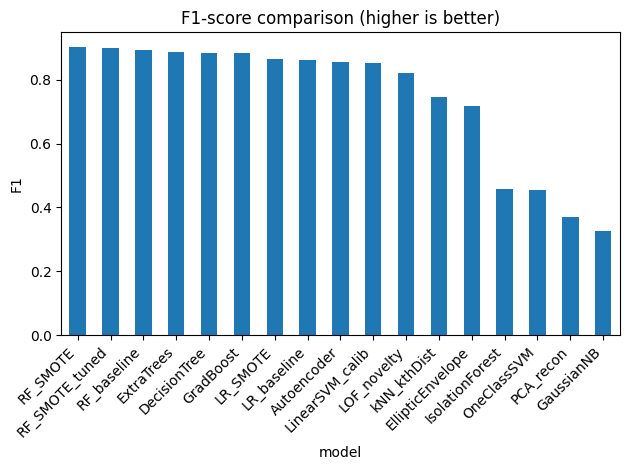

In [17]:

# Merge metric dicts into one table
all_metrics = {}
all_metrics.update(metrics_store)
all_metrics.update(anom_metrics)

cmp = pd.DataFrame(all_metrics).T
display(cmp.sort_values("f1", ascending=False))

plt.figure()
cmp["f1"].sort_values(ascending=False).plot(kind="bar")
plt.title("F1-score comparison (higher is better)")
plt.xlabel("model"); plt.ylabel("F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
